In [3]:
# STEP 0: Load the dataset from the uploaded CSV
import pandas as pd

df = pd.read_csv("D:/15 Years Stock Data.csv")
print(df.head())


         Date  Close_AAPL  Close_AMZN  Close_GOOGL  Close_MSFT  Close_NVDA  \
0  2010-01-04    6.440330      6.6950    15.609805   23.254051    0.423884   
1  2010-01-05    6.451465      6.7345    15.541064   23.261557    0.430073   
2  2010-01-06    6.348847      6.6125    15.149294   23.118809    0.432824   
3  2010-01-07    6.337109      6.5000    14.796624   22.878376    0.424342   
4  2010-01-08    6.379242      6.6760    14.993881   23.036165    0.425259   

   High_AAPL  High_AMZN  High_GOOGL  High_MSFT  ...  Open_AAPL  Open_AMZN  \
0   6.455075     6.8305   15.678546  23.366752  ...   6.422875     6.8125   
1   6.487878     6.7740   15.636953  23.366746  ...   6.458086     6.6715   
2   6.477046     6.7365   15.587638  23.351725  ...   6.451466     6.7300   
3   6.379842     6.6160   15.192630  23.066212  ...   6.372319     6.6005   
4   6.379844     6.6840   15.024515  23.201460  ...   6.328685     6.5280   

   Open_GOOGL  Open_MSFT  Open_NVDA  Volume_AAPL  Volume_AMZN  Volum

In [5]:
print(df.columns.tolist())



['Date', 'Close_AAPL', 'Close_AMZN', 'Close_GOOGL', 'Close_MSFT', 'Close_NVDA', 'High_AAPL', 'High_AMZN', 'High_GOOGL', 'High_MSFT', 'High_NVDA', 'Low_AAPL', 'Low_AMZN', 'Low_GOOGL', 'Low_MSFT', 'Low_NVDA', 'Open_AAPL', 'Open_AMZN', 'Open_GOOGL', 'Open_MSFT', 'Open_NVDA', 'Volume_AAPL', 'Volume_AMZN', 'Volume_GOOGL', 'Volume_MSFT', 'Volume_NVDA']


In [6]:
# STEP 1: Keep only available closing prices
close_prices = df[['Date', 'Close_AAPL', 'Close_MSFT', 'Close_GOOGL', 'Close_AMZN', 'Close_NVDA']].copy()
print(close_prices.head())


         Date  Close_AAPL  Close_MSFT  Close_GOOGL  Close_AMZN  Close_NVDA
0  2010-01-04    6.440330   23.254051    15.609805      6.6950    0.423884
1  2010-01-05    6.451465   23.261557    15.541064      6.7345    0.430073
2  2010-01-06    6.348847   23.118809    15.149294      6.6125    0.432824
3  2010-01-07    6.337109   22.878376    14.796624      6.5000    0.424342
4  2010-01-08    6.379242   23.036165    14.993881      6.6760    0.425259


In [7]:
# STEP 2: Clean and index the dates
close_prices['Date'] = pd.to_datetime(close_prices['Date'])  # convert to datetime
close_prices.set_index('Date', inplace=True)                 # set date as index
close_prices.sort_index(inplace=True)                        # sort just in case

# Preview the cleaned DataFrame
print(close_prices.head())


            Close_AAPL  Close_MSFT  Close_GOOGL  Close_AMZN  Close_NVDA
Date                                                                   
2010-01-04    6.440330   23.254051    15.609805      6.6950    0.423884
2010-01-05    6.451465   23.261557    15.541064      6.7345    0.430073
2010-01-06    6.348847   23.118809    15.149294      6.6125    0.432824
2010-01-07    6.337109   22.878376    14.796624      6.5000    0.424342
2010-01-08    6.379242   23.036165    14.993881      6.6760    0.425259


In [8]:
import numpy as np

# STEP 3: Calculate daily log returns
log_returns = np.log(close_prices / close_prices.shift(1))

# Preview the log return values
print(log_returns.head())


            Close_AAPL  Close_MSFT  Close_GOOGL  Close_AMZN  Close_NVDA
Date                                                                   
2010-01-04         NaN         NaN          NaN         NaN         NaN
2010-01-05    0.001728    0.000323    -0.004413    0.005883    0.014497
2010-01-06   -0.016034   -0.006156    -0.025532   -0.018282    0.006376
2010-01-07   -0.001851   -0.010454    -0.023555   -0.017160   -0.019792
2010-01-08    0.006627    0.006873     0.013243    0.026717    0.002159


In [9]:
# Calculate Historical VaR at 95% confidence level
# (i.e., 5% quantile of daily portfolio return distribution)

# First, assume equal-weighted portfolio
weights = np.array([1/5] * 5)  # 5 stocks

# Calculate daily portfolio returns
portfolio_returns = log_returns.dot(weights)

# Compute 5% quantile (i.e., 1-day VaR at 95% confidence)
historical_var_95 = np.percentile(portfolio_returns.dropna(), 5)

print(f"Historical VaR (95% confidence, 1-day): {historical_var_95:.4f}")


Historical VaR (95% confidence, 1-day): -0.0263


In [10]:
from scipy.stats import norm

# STEP 5: Parametric VaR (95% confidence)
confidence_level = 0.95
z_score = norm.ppf(1 - confidence_level)

# Portfolio volatility (standard deviation)
portfolio_std = portfolio_returns.std()

# Parametric VaR
parametric_var_95 = z_score * portfolio_std

print(f"Parametric VaR (95% confidence, 1-day): {parametric_var_95:.4f}")


Parametric VaR (95% confidence, 1-day): -0.0261


In [11]:
# STEP 6: Monte Carlo Simulation for VaR

# Parameters
np.random.seed(42)  # for reproducibility
num_simulations = 10000
mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

# Simulate 10,000 one-day returns
simulated_returns = np.random.normal(loc=mean_return, scale=std_return, size=num_simulations)

# Calculate 5th percentile (VaR at 95% confidence)
monte_carlo_var_95 = np.percentile(simulated_returns, 5)

print(f"Monte Carlo VaR (95% confidence, 1-day): {monte_carlo_var_95:.4f}")


Monte Carlo VaR (95% confidence, 1-day): -0.0253


In [12]:
# STEP 7: Summary of VaR values
print("📊 1-Day 95% VaR Comparison (as % loss):")
print(f"Historical VaR     : {historical_var_95:.4%}")
print(f"Parametric VaR     : {parametric_var_95:.4%}")
print(f"Monte Carlo VaR    : {monte_carlo_var_95:.4%}")


📊 1-Day 95% VaR Comparison (as % loss):
Historical VaR     : -2.6278%
Parametric VaR     : -2.6129%
Monte Carlo VaR    : -2.5318%


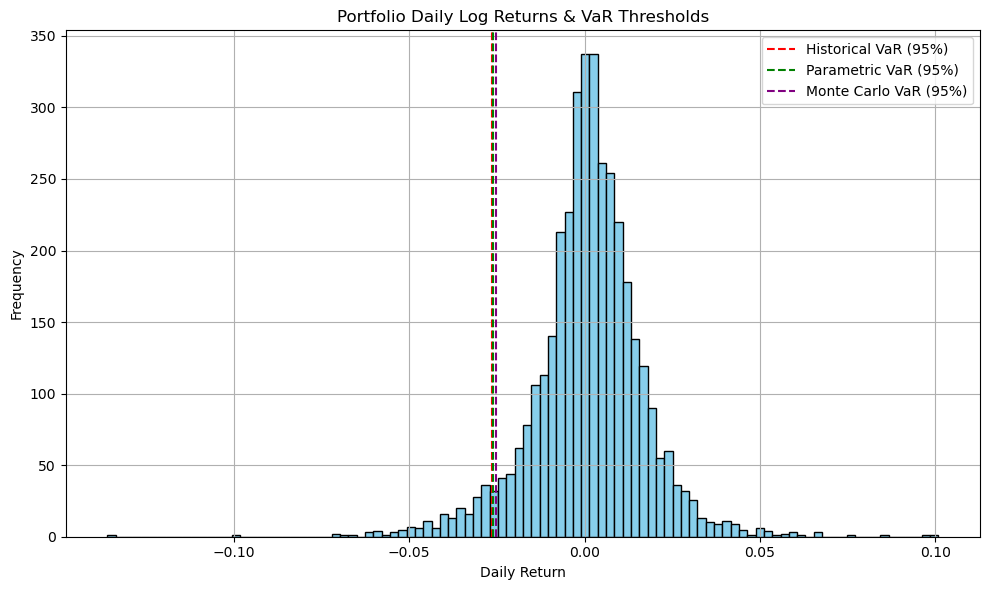

In [13]:
import matplotlib.pyplot as plt

# STEP 8: Histogram of Portfolio Returns with VaR line
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns.dropna(), bins=100, color='skyblue', edgecolor='black')
plt.axvline(historical_var_95, color='red', linestyle='--', label='Historical VaR (95%)')
plt.axvline(parametric_var_95, color='green', linestyle='--', label='Parametric VaR (95%)')
plt.axvline(monte_carlo_var_95, color='purple', linestyle='--', label='Monte Carlo VaR (95%)')
plt.title('Portfolio Daily Log Returns & VaR Thresholds')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# STEP 9: Conditional Value at Risk (CVaR) - Historical
# CVaR is the average loss in the worst 5% of days

cvar_95 = portfolio_returns[portfolio_returns <= historical_var_95].mean()

print(f"Conditional VaR (CVaR) at 95% confidence: {cvar_95:.4f}")


Conditional VaR (CVaR) at 95% confidence: -0.0382


In [15]:
# STEP 10: Simulate portfolio value after stress scenarios
stress_levels = [-0.05, -0.10, -0.15]  # 5%, 10%, 15% drops

print("🔻 Stress Test Results (Portfolio Return):")
for drop in stress_levels:
    stressed_returns = np.array([drop] * len(weights))  # apply uniform shock to all assets
    stressed_portfolio_return = np.dot(weights, stressed_returns)
    print(f"Market drops {int(-drop*100)}% on all assets → Portfolio return: {stressed_portfolio_return:.2%}")


🔻 Stress Test Results (Portfolio Return):
Market drops 5% on all assets → Portfolio return: -5.00%
Market drops 10% on all assets → Portfolio return: -10.00%
Market drops 15% on all assets → Portfolio return: -15.00%
